In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

ruta_dataset = "/content/drive/MyDrive/TFM/dataset_modelo_v2.csv"

df = pd.read_csv(
    ruta_dataset,
    sep=";",
    encoding="utf-8-sig"
)

df.shape

(333523, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333523 entries, 0 to 333522
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   cliente          333523 non-null  int64  
 1   periodo          333523 non-null  object 
 2   fec_lec_ant_1    333523 non-null  object 
 3   fec_lec_act_1    333523 non-null  object 
 4   dif_dias_1       333523 non-null  float64
 5   m3_cons_1        333523 non-null  float64
 6   n_usuarios       333523 non-null  int64  
 7   ruta             328768 non-null  object 
 8   des_tip_cli      333523 non-null  object 
 9   des_sub_tip_cli  333523 non-null  object 
 10  tipo_inc_1       333523 non-null  object 
 11  incidencia_1     333523 non-null  object 
 12  anio             333523 non-null  float64
 13  mes              333523 non-null  float64
 14  bimestre         333523 non-null  float64
 15  m3_dia           333523 non-null  float64
dtypes: float64(6), int64(2), object(8)
mem

In [ ]:
df.head()

,cliente,periodo,fec_lec_ant_1,fec_lec_act_1,dif_dias_1,m3_cons_1,n_usuarios,ruta,des_tip_cli,des_sub_tip_cli,tipo_inc_1,incidencia_1,anio,mes,bimestre,m3_dia
0,42,245 SEP-OCT/24,2024-08-18,2024-10-16,59.0,3.0,1,1 GUIA ALTO,Doméstica,General,Defecto,Defecto,2024.0,10.0,5.0,0.050847
1,44,245 SEP-OCT/24,2024-08-19,2024-10-17,59.0,0.0,1,1 GUIA ALTO,Doméstica,General,Iguales,Consumo Cero,2024.0,10.0,5.0,0.000000
2,45,245 SEP-OCT/24,2024-08-18,2024-10-16,59.0,2.0,1,1 GUIA ALTO,Doméstica,General,Defecto,Defecto,2024.0,10.0,5.0,0.033898
3,46,245 SEP-OCT/24,2024-08-18,2024-10-16,59.0,3.0,1,1 GUIA ALTO,Doméstica,General,Normal,Normal,2024.0,10.0,5.0,0.050847
4,47,245 SEP-OCT/24,2024-08-18,2024-10-16,59.0,48.0,1,1 GUIA ALTO,Doméstica,General,Normal,Normal,2024.0,10.0,5.0,0.813559


In [ ]:
df["fec_lec_ant_1"] = pd.to_datetime(df["fec_lec_ant_1"], errors="coerce")
df["fec_lec_act_1"] = pd.to_datetime(df["fec_lec_act_1"], errors="coerce")

df["m3_cons_1"] = pd.to_numeric(df["m3_cons_1"], errors="coerce")
df["dif_dias_1"] = pd.to_numeric(df["dif_dias_1"], errors="coerce")
df["m3_dia"] = pd.to_numeric(df["m3_dia"], errors="coerce")

In [ ]:
dataset_bimestral = (
    df
    .groupby("periodo")
    .agg(
        consumo_total_m3=("m3_cons_1", "sum"),
        consumo_medio_m3=("m3_cons_1", "mean"),
        consumo_medio_diario_m3=("m3_dia", "mean"),
        abonados=("cliente", "count"),
        domesticos=("des_tip_cli", lambda x: (x == "Doméstica").sum()),
        industriales=("des_tip_cli", lambda x: (x == "Industrial").sum()),
        incidencias_sin_lectura=("tipo_inc_1", lambda x: (x == "Sin lectura").sum()),
        incidencias_normales=("tipo_inc_1", lambda x: (x == "Normal").sum())
    )
    .reset_index()
)

dataset_bimestral

,periodo,consumo_total_m3,consumo_medio_m3,consumo_medio_diario_m3,abonados,domesticos,industriales,incidencias_sin_lectura,incidencias_normales
0,201 ENE-FEB/20,238430.0,24.421797,0.423523,9763,0,0,544,4207
1,202 MAR-ABR/20,222732.0,22.746324,0.377438,9792,0,0,9053,423
2,203 MAY-JUN/20,247689.0,25.194690,0.420694,9831,0,0,880,3833
3,204 JUL-AGO/20,295567.0,28.793668,0.452773,10265,0,0,1348,4174
4,205 SEP-OCT/20,273201.0,27.702393,0.448482,9862,0,0,1217,4268
5,206 NOV-DIC/20,246651.0,24.939434,0.413628,9890,0,0,896,4836
6,221 ENE-FEB/22,243489.0,24.242234,0.398167,10044,0,0,463,4567
7,222 MAR-ABR/22,243635.0,24.225415,0.392755,10057,0,0,403,4505
8,223 MAY-JUN/22,283579.0,27.069397,0.437469,10476,0,0,413,4516
9,224 JUL-AGO/22,269680.0,26.708923,0.449856,10097,0,0,411,4569


Ordenar los periodos

In [ ]:
dataset_bimestral["codigo_periodo"] = dataset_bimestral["periodo"].str.extract(r"(\d+)").astype(int)

dataset_bimestral = dataset_bimestral.sort_values("codigo_periodo").reset_index(drop=True)

dataset_bimestral

,periodo,consumo_total_m3,consumo_medio_m3,consumo_medio_diario_m3,abonados,domesticos,industriales,incidencias_sin_lectura,incidencias_normales,codigo_periodo
0,201 ENE-FEB/20,238430.0,24.421797,0.423523,9763,0,0,544,4207,201
1,202 MAR-ABR/20,222732.0,22.746324,0.377438,9792,0,0,9053,423,202
2,203 MAY-JUN/20,247689.0,25.194690,0.420694,9831,0,0,880,3833,203
3,204 JUL-AGO/20,295567.0,28.793668,0.452773,10265,0,0,1348,4174,204
4,205 SEP-OCT/20,273201.0,27.702393,0.448482,9862,0,0,1217,4268,205
5,206 NOV-DIC/20,246651.0,24.939434,0.413628,9890,0,0,896,4836,206
6,221 ENE-FEB/22,243489.0,24.242234,0.398167,10044,0,0,463,4567,221
7,222 MAR-ABR/22,243635.0,24.225415,0.392755,10057,0,0,403,4505,222
8,223 MAY-JUN/22,283579.0,27.069397,0.437469,10476,0,0,413,4516,223
9,224 JUL-AGO/22,269680.0,26.708923,0.449856,10097,0,0,411,4569,224


Variables temporales del agregado

In [ ]:
dataset_bimestral["anio"] = 2000 + (dataset_bimestral["codigo_periodo"] // 10)
dataset_bimestral["bimestre"] = dataset_bimestral["codigo_periodo"] % 10

Comprobaciones

In [ ]:
dataset_bimestral.shape

(32, 12)

In [ ]:
dataset_bimestral[[
    "periodo",
    "anio",
    "bimestre",
    "consumo_total_m3",
    "abonados"
]]

,periodo,anio,bimestre,consumo_total_m3,abonados
0,201 ENE-FEB/20,2020,1,238430.0,9763
1,202 MAR-ABR/20,2020,2,222732.0,9792
2,203 MAY-JUN/20,2020,3,247689.0,9831
3,204 JUL-AGO/20,2020,4,295567.0,10265
4,205 SEP-OCT/20,2020,5,273201.0,9862
5,206 NOV-DIC/20,2020,6,246651.0,9890
6,221 ENE-FEB/22,2022,1,243489.0,10044
7,222 MAR-ABR/22,2022,2,243635.0,10057
8,223 MAY-JUN/22,2022,3,283579.0,10476
9,224 JUL-AGO/22,2022,4,269680.0,10097


Guardar dataset bimestral

In [ ]:
ruta_salida = "/content/drive/MyDrive/TFM/dataset_bimestral_v1.csv"

dataset_bimestral.to_csv(
    ruta_salida,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

ruta_salida

'/content/drive/MyDrive/TFM/dataset_bimestral_v1.csv'

Evolución del consumo

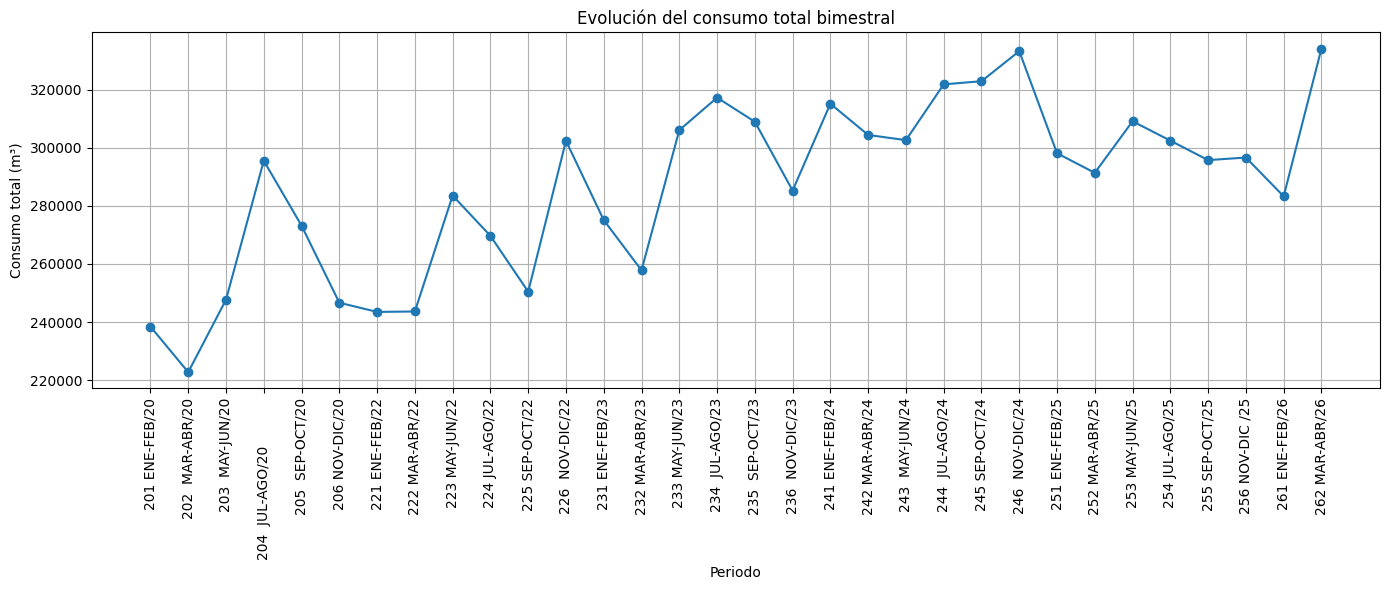

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    dataset_bimestral["periodo"],
    dataset_bimestral["consumo_total_m3"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Evolución del consumo total bimestral")
plt.ylabel("Consumo total (m³)")
plt.xlabel("Periodo")

plt.grid(True)

plt.tight_layout()
plt.show()

Evolución de abonados

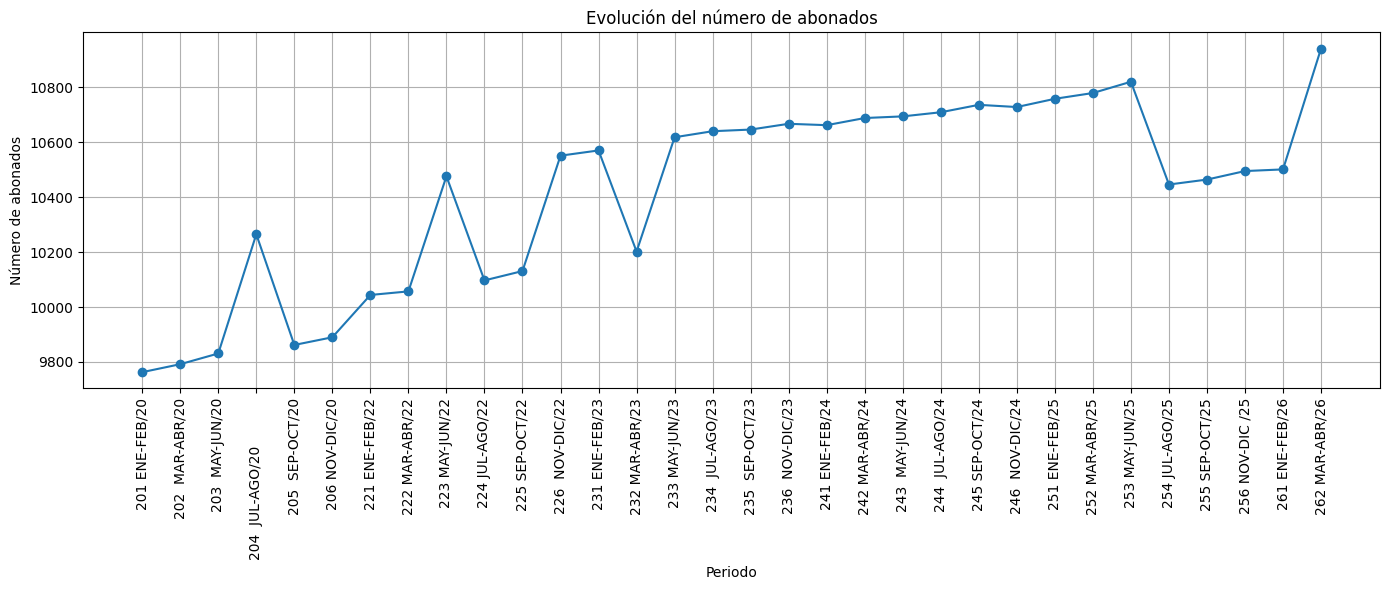

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    dataset_bimestral["periodo"],
    dataset_bimestral["abonados"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Evolución del número de abonados")
plt.ylabel("Número de abonados")
plt.xlabel("Periodo")

plt.grid(True)

plt.tight_layout()
plt.show()

COnsumo medio por abonado

In [ ]:
dataset_bimestral["consumo_medio_abonado"] = (
    dataset_bimestral["consumo_total_m3"] /
    dataset_bimestral["abonados"]
)

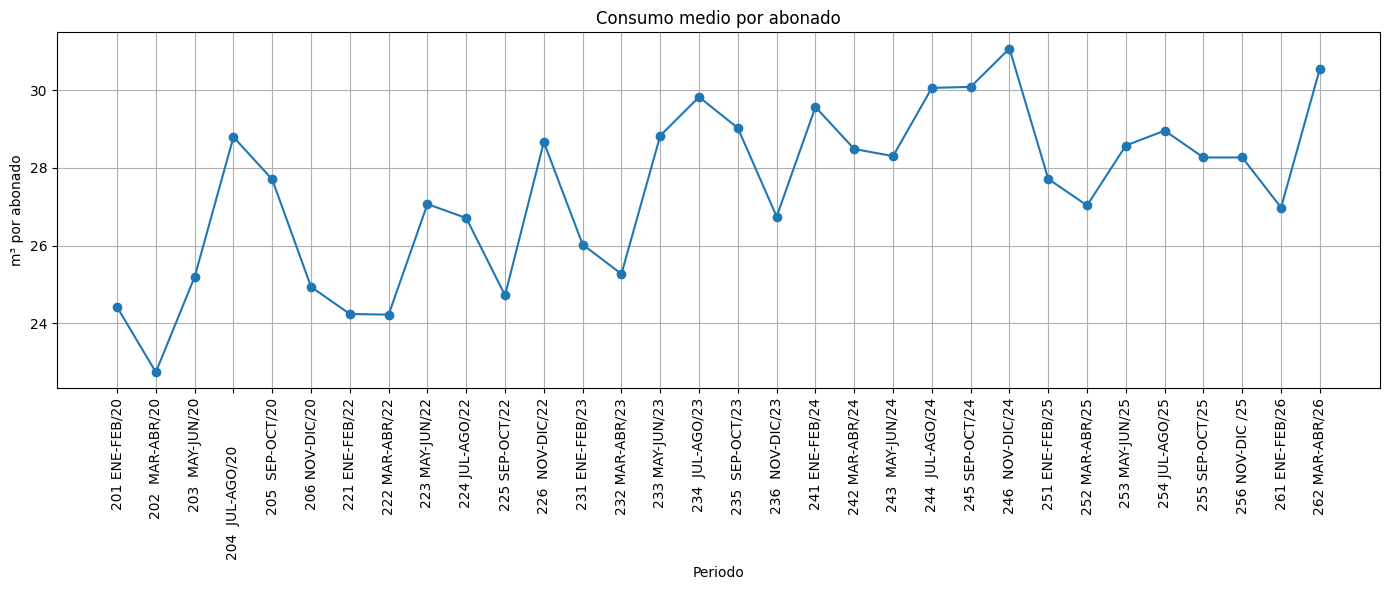

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    dataset_bimestral["periodo"],
    dataset_bimestral["consumo_medio_abonado"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Consumo medio por abonado")
plt.ylabel("m³ por abonado")
plt.xlabel("Periodo")

plt.grid(True)

plt.tight_layout()
plt.show()

Volumen de agua por bimestres

In [ ]:
consumo_estacional = (
    dataset_bimestral
    .groupby("bimestre")["consumo_total_m3"]
    .mean()
)

consumo_estacional

,consumo_total_m3
bimestre,
1,275618.666667
2,275708.000000
3,289839.400000
4,301384.000000
5,290278.200000
6,292868.400000


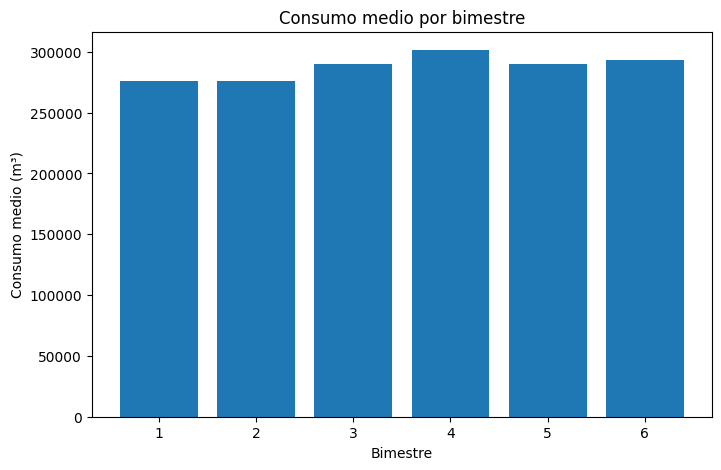

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    consumo_estacional.index.astype(str),
    consumo_estacional.values
)

plt.title("Consumo medio por bimestre")
plt.xlabel("Bimestre")
plt.ylabel("Consumo medio (m³)")

plt.show()

Consumo medio por abonado según bimestre

In [ ]:
consumo_estacional_abonado = (
    dataset_bimestral
    .groupby("bimestre")["consumo_medio_abonado"]
    .mean()
)

consumo_estacional_abonado

,consumo_medio_abonado
bimestre,
1,26.491692
2,26.384864
3,27.593637
4,28.867750
5,27.959398
6,27.936844


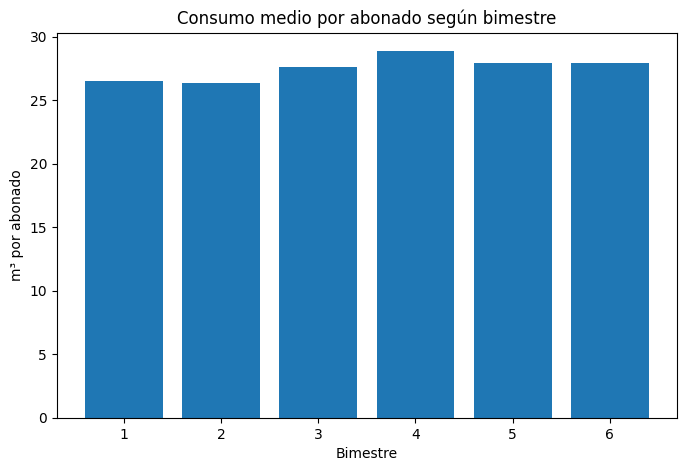

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    consumo_estacional_abonado.index.astype(str),
    consumo_estacional_abonado.values
)

plt.title("Consumo medio por abonado según bimestre")
plt.xlabel("Bimestre")
plt.ylabel("m³ por abonado")

plt.show()

Análisis territorial

In [ ]:
consumo_ruta = (
    df
    .groupby("ruta")["m3_cons_1"]
    .sum()
    .sort_values(ascending=False)
)

consumo_ruta.head(20)

,m3_cons_1
ruta,
1 GUIA ALTO,1106760.0
7 ALCALA BAJO,719508.0
14 CHIO,711836.0
4 PLAYA ALTO,671528.0
21 FONSALIA Y PLAYA NUE.,638900.0
9 ALCALA DISEM.,599986.0
5 PLAYA BAJO,565238.0
8 ALCALA ALTO,546651.0
24 VARADERO,526355.0


In [ ]:
abonados_ruta = (
    df
    .groupby("ruta")["cliente"]
    .count()
    .sort_values(ascending=False)
)

abonados_ruta.head(20)

,cliente
ruta,
1 GUIA ALTO,50172
4 PLAYA ALTO,35299
7 ALCALA BAJO,33702
21 FONSALIA Y PLAYA NUE.,32806
5 PLAYA BAJO,28079
14 CHIO,25483
8 ALCALA ALTO,22497
13 PIEDRA HINCADA,15148
11 TEJINA,12669


Consumo medio por abonado y ruta

In [ ]:
consumo_medio_ruta = (
    df
    .groupby("ruta")
    .agg(
        consumo_total=("m3_cons_1", "sum"),
        abonados=("cliente", "count")
    )
)

consumo_medio_ruta["m3_por_abonado"] = (
    consumo_medio_ruta["consumo_total"] /
    consumo_medio_ruta["abonados"]
)

consumo_medio_ruta.sort_values(
    "m3_por_abonado",
    ascending=False
).head(20)

,consumo_total,abonados,m3_por_abonado
ruta,,,
9 ALCALA DISEM.,599986.0,1628,368.541769
ABAMA,28256.0,154,183.480519
ALCALA DISEM.,32368.0,213,151.962441
20 ABAMA,265652.0,1923,138.144566
24 VARADERO,526355.0,6812,77.268790
3 GUIA DISEMINADO,238686.0,6129,38.943710
10 CUEVA DEL POLVO,36411.0,1021,35.662096
22 VERA DE ERQUES,216697.0,6241,34.721519
6 PLAYA DISEM.,60745.0,1791,33.916806


In [ ]:
consumo_total_ruta = (
    df
    .groupby("ruta")["m3_cons_1"]
    .sum()
    .sort_values(ascending=False)
)

consumo_total_ruta.head(20)

,m3_cons_1
ruta,
1 GUIA ALTO,1106760.0
7 ALCALA BAJO,719508.0
14 CHIO,711836.0
4 PLAYA ALTO,671528.0
21 FONSALIA Y PLAYA NUE.,638900.0
9 ALCALA DISEM.,599986.0
5 PLAYA BAJO,565238.0
8 ALCALA ALTO,546651.0
24 VARADERO,526355.0


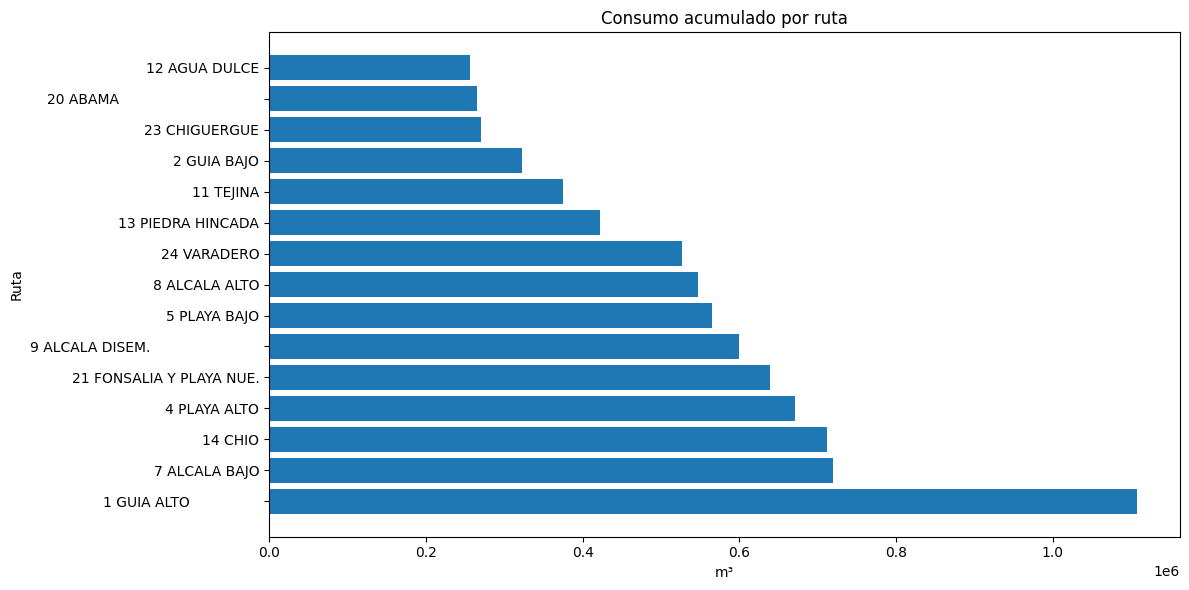

In [ ]:
top15 = consumo_total_ruta.head(15)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top15.index,
    top15.values
)

plt.title("Consumo acumulado por ruta")
plt.xlabel("m³")
plt.ylabel("Ruta")

plt.tight_layout()
plt.show()

Resumen

TOP 20 RUTAS POR CONSUMO


,consumo_total,registros,m3_por_registro,porcentaje_consumo
ruta,,,,
1 GUIA ALTO,1106760.0,50172,22.059316,12.165914
7 ALCALA BAJO,719508.0,33702,21.349119,7.909098
14 CHIO,711836.0,25483,27.933760,7.824764
4 PLAYA ALTO,671528.0,35299,19.023995,7.381684
21 FONSALIA Y PLAYA NUE.,638900.0,32806,19.475096,7.023025
9 ALCALA DISEM.,599986.0,1628,368.541769,6.595268
5 PLAYA BAJO,565238.0,28079,20.130275,6.213305
8 ALCALA ALTO,546651.0,22497,24.298840,6.008990
24 VARADERO,526355.0,6812,77.268790,5.785888


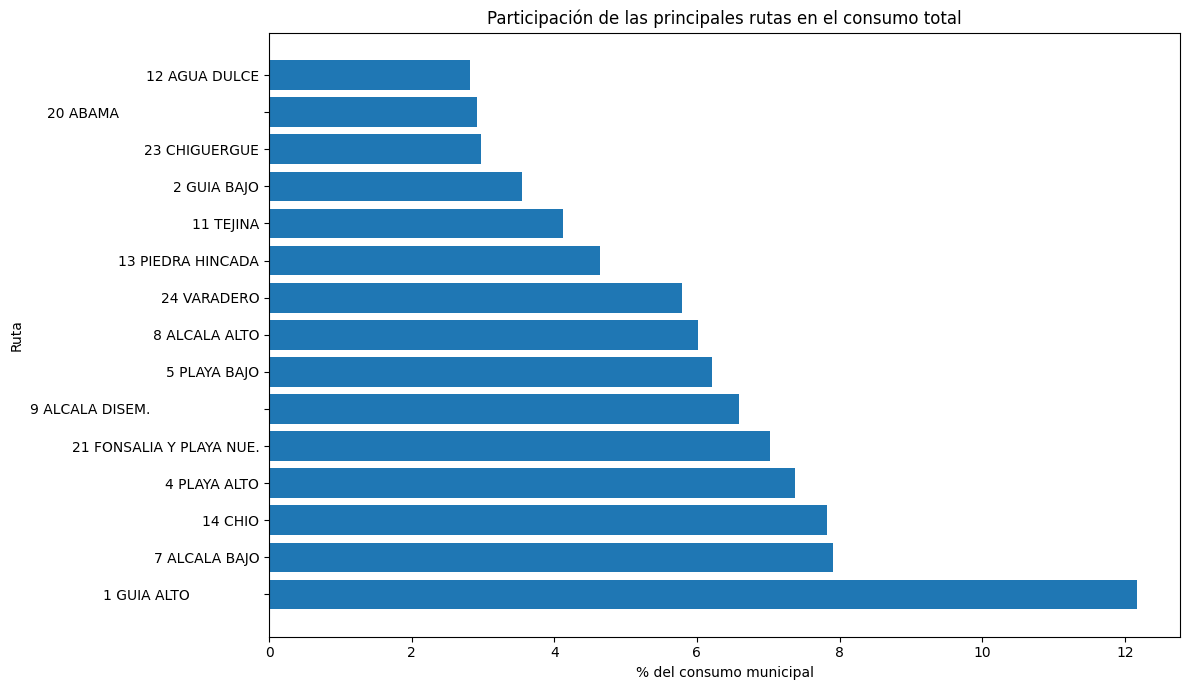


Porcentaje acumulado de las 5 principales rutas:
42.3 %

Porcentaje acumulado de las 10 principales rutas:
71.54 %

Porcentaje acumulado de las 15 principales rutas:
87.93 %


In [ ]:

ruta_resumen = (
    df
    .groupby("ruta")
    .agg(
        consumo_total=("m3_cons_1", "sum"),
        registros=("cliente", "count")
    )
)

# Consumo medio por registro
ruta_resumen["m3_por_registro"] = (
    ruta_resumen["consumo_total"] /
    ruta_resumen["registros"]
)

# Peso porcentual sobre el consumo municipal
consumo_total_municipio = ruta_resumen["consumo_total"].sum()

ruta_resumen["porcentaje_consumo"] = (
    ruta_resumen["consumo_total"] /
    consumo_total_municipio * 100
)

# Ordenar por consumo total
ruta_resumen = ruta_resumen.sort_values(
    "consumo_total",
    ascending=False
)

# Mostrar las 20 principales rutas
print("TOP 20 RUTAS POR CONSUMO")
display(ruta_resumen.head(20))

# =====================================================
# GRÁFICO DE PESO RELATIVO
# =====================================================

import matplotlib.pyplot as plt

top15 = ruta_resumen.head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top15.index,
    top15["porcentaje_consumo"]
)

plt.xlabel("% del consumo municipal")
plt.ylabel("Ruta")
plt.title("Participación de las principales rutas en el consumo total")

plt.tight_layout()
plt.show()

# =====================================================
# CONCENTRACIÓN DEL CONSUMO
# =====================================================

print("\nPorcentaje acumulado de las 5 principales rutas:")
print(round(ruta_resumen.head(5)["porcentaje_consumo"].sum(),2), "%")

print("\nPorcentaje acumulado de las 10 principales rutas:")
print(round(ruta_resumen.head(10)["porcentaje_consumo"].sum(),2), "%")

print("\nPorcentaje acumulado de las 15 principales rutas:")
print(round(ruta_resumen.head(15)["porcentaje_consumo"].sum(),2), "%")